In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
new = pd.read_excel('data/PosTip_Data_for_Prosumers.xlsx')
print(len(new))
new.sample(3)

8957


,Year,Value,Innovation Name,Indicator Number,Indicator Name,Description,Metric,Data Source,Comments,Spatial Scale
8651,2013,0.475000,Third-Party Solar Leasing,3.2,Adopter Characteristics,% third party owned systems (income = $150k–$2...,Share of solar leasing among income $150k–$200...,"Lawrence Berkeley National Laboratory, Energy ...",Share of third-party owned (leased) solar syst...,California
1716,2009,96.100000,Households Electricity Access,1.1,Adoption over Time,Access to electricity as share of total popula...,% of population with access to electricity,"World Bank, World Development Indicators, indi...",Access to electricity as percentage of total p...,Colombia
72,2017,0.014997,EV (PHEV + BEV),1.1,Adoption over Time,Total BEV and PHEV share of new Light Duty Veh...,EV (PHEV + BEV) share of total new LDV sale,U.S. Bureau of Transportation Statistics (BTS)...,New vehicle retail-equivalent sales; includes ...,United States


18


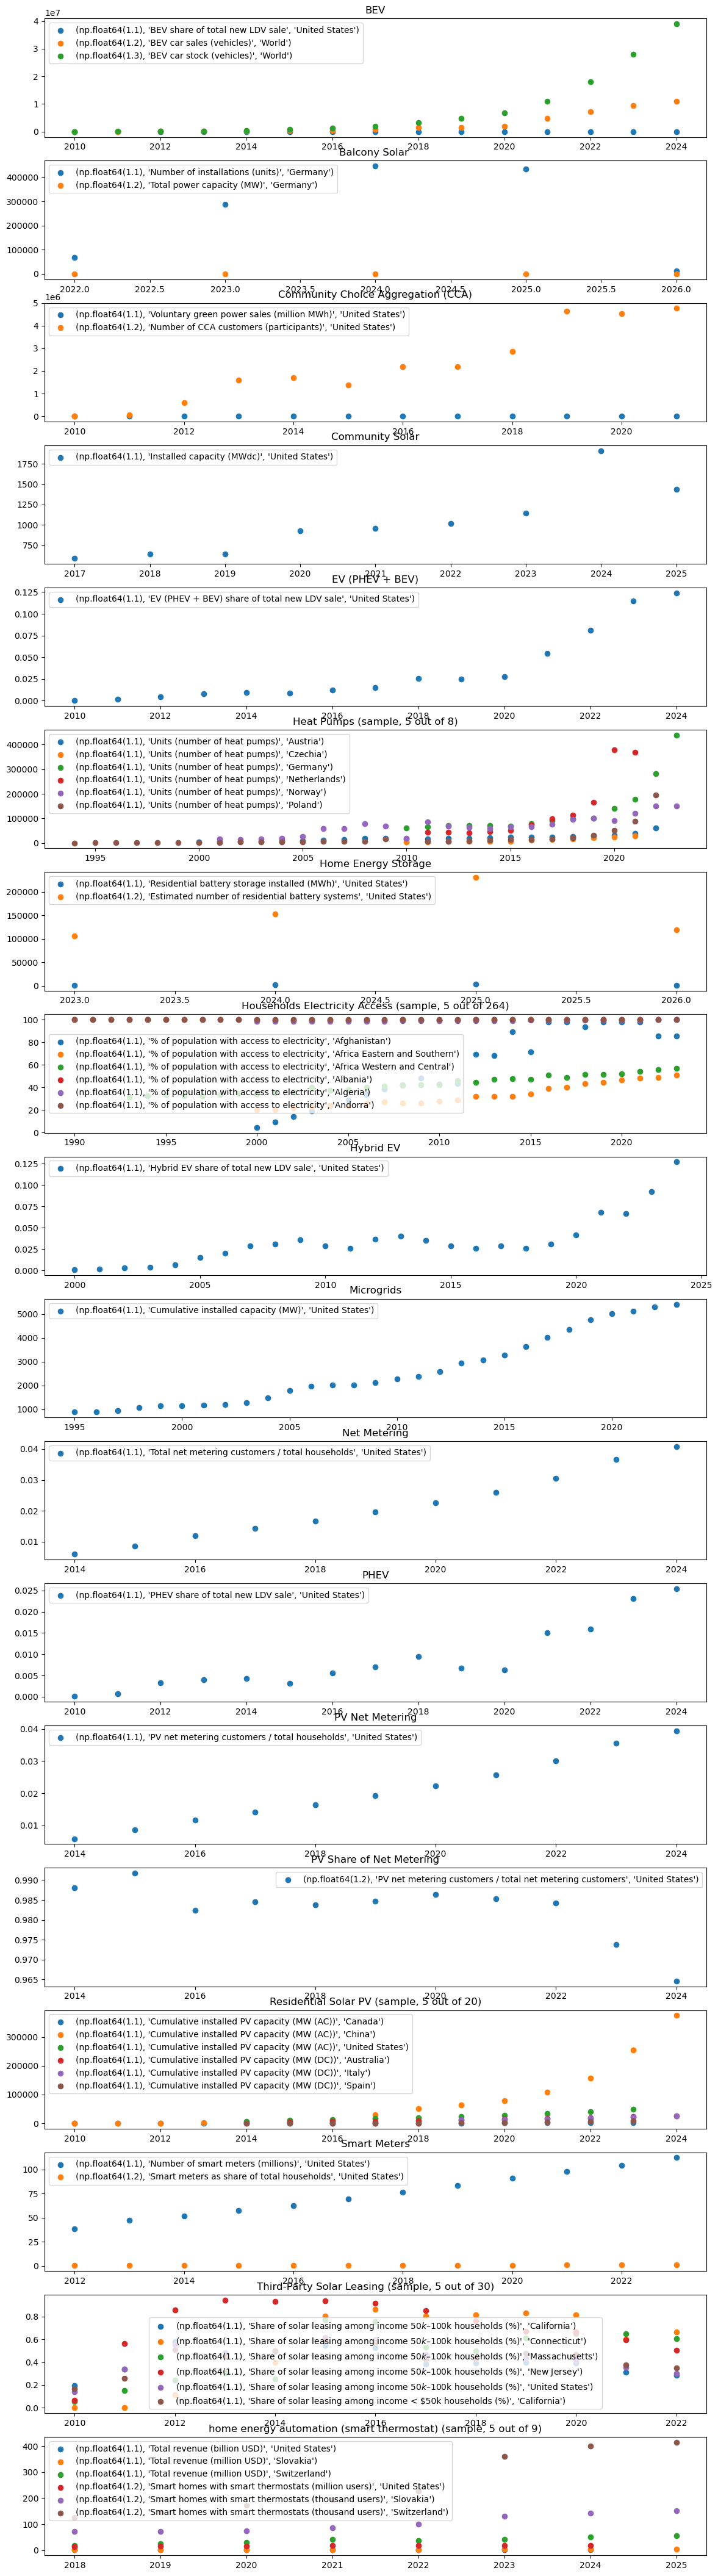

In [18]:
innos = new.groupby('Innovation Name')
print(len(innos))
fix, axs = plt.subplots(nrows=len(innos), figsize=(14,3*len(innos)))
for (name, inno), ax in zip({i[0]:i[1] for i in list(innos)}.items(), axs):
    g = inno.groupby(['Indicator Number', 'Metric', 'Spatial Scale'])
    i = 0
    if len(g) > 5: name += ' (sample, 5 out of {})'.format(len(g))
    for ts_name, ts in {i[0]:i[1] for i in list(g)}.items():
        ax.scatter(x=ts['Year'], y=ts['Value'], label=ts_name)
        i += 1
        if i > 5: break
    ax.legend()
    ax.set_title(name)

In [24]:
old = pd.read_csv('data/adjusted_datasets_v28.csv')
len(old)
old.sample()

,Year,Value,Innovation Name,Indicator Number,Indicator Name,Description,Metric,Data Source,Comments,Spatial Scale,File,Sheet
26507,2013,72.0,digital (non-cash) payments,3.3,Risk & Uncertainty (Shared Expectations),scientific publications,# publications,Web of Science,Web of Science,Global,/Users/dani/Energy Emissions/Priorities Attemp...,ALL DATA


In [28]:
merged = pd.concat([old, new]).reset_index(drop=True)
missing = merged.loc[merged[[c for c in merged.columns if not c in ['Data Source', 'Comments', 'File', 'Sheet']]].isna().any(axis=1)]
len(missing)

152

In [31]:
missing.groupby(['Innovation Name', 'Indicator Number', 'Metric', 'Spatial Scale'])['Year'].count()

Innovation Name      Indicator Number  Metric        Spatial Scale               
car sharing          1.1               market share  Germany                          1
co-housing           1.1               market share  Canton de Vaud (Switzerland)    12
firm ESG reporting   1.1               market share  Africa                          14
                                                     Asia                            17
                                                     LatinAmericaCarib               15
                                                     North America                   17
                                                     Oceania                         13
                                                     global                          18
passive buildings    1.1               market share  Austria                          1
                                                     Global                          34
reducing food waste  1.1              

In [32]:
merged.to_csv('data/adjusted_datasets_v29.csv')